In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

BASE_PATH = r"C:\Users\MEL\Downloads\DATA\SEMANA 4\Proyect_Lab\Proyecto_lab"
df = pd.read_csv(f"{BASE_PATH}\\data\\clean\\trials_clean.csv")

print(f"✅ Datos cargados: {df.shape}")
df.head()

✅ Datos cargados: (4000, 12)


,nct_id,title,status,phase,start_date,enrollment,sponsor,sponsor_class,conditions,countries,start_year,primary_country
0,NCT06423690,First in Human Study for the Assessment of Saf...,Recruiting,Unknown,2024-11-01,15,Snipe Medical,INDUSTRY,Lung Cancer,United Kingdom; Spain; Israel,2024.0,United Kingdom
1,NCT00257790,The Tobramycin Study,Completed,Phase 4,NaN,210,Oslo University Hospital,OTHER,Neutropenia; Fever; Cancer,Unknown,NaN,Unknown
2,NCT00369590,VEGF Trap in Treating Patients With Recurrent ...,Completed,Phase 2,NaN,58,National Cancer Institute (NCI),NIH,Adult Anaplastic Astrocytoma; Adult Anaplastic...,United States,NaN,United States
3,NCT00513097,Curbing Tobacco Use in Suburban and Rural Schools,Completed,Phase 1,2006-07-25,1289,M.D. Anderson Cancer Center,OTHER,Tobacco Use Cessation,United States,2006.0,United States
4,NCT04501497,Prospective Multicenter Observational Study of...,Completed,Unknown,2020-08-21,1221,Chugai Pharmaceutical,INDUSTRY,Non-small Cell Lung Cancer; Extensive Disease ...,Japan,2020.0,Japan


## Análisis Exploratorio de Datos (EDA)
Visualizamos los datos limpios para responder nuestras hipótesis de investigación.

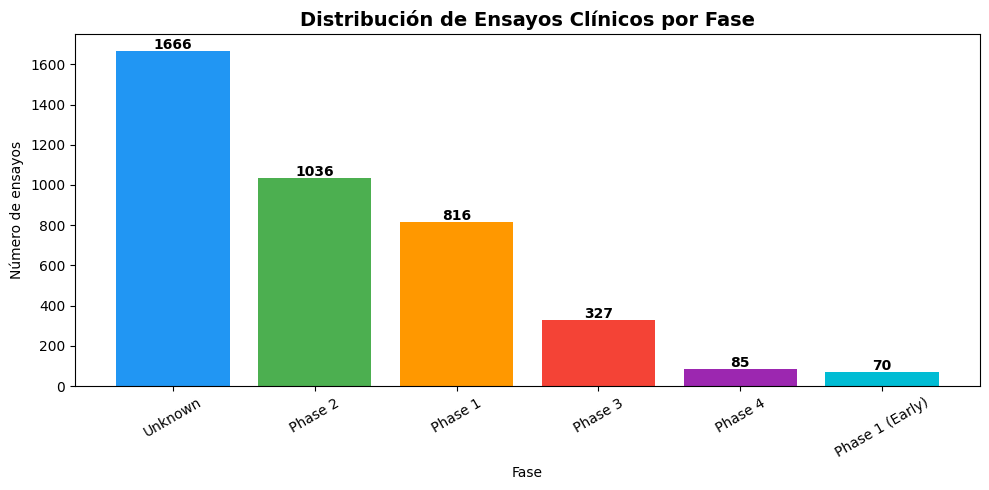

✅ Gráfico guardado


In [2]:
# Hipótesis 3: Distribución de ensayos por fase
fig, ax = plt.subplots(figsize=(10, 5))
phase_counts = df["phase"].value_counts()
colors = ["#2196F3", "#4CAF50", "#FF9800", "#F44336", "#9C27B0", "#00BCD4"]
ax.bar(phase_counts.index, phase_counts.values, color=colors[:len(phase_counts)])
ax.set_title("Distribución de Ensayos Clínicos por Fase", fontsize=14, fontweight="bold")
ax.set_xlabel("Fase")
ax.set_ylabel("Número de ensayos")
plt.xticks(rotation=30)
for i, v in enumerate(phase_counts.values):
    ax.text(i, v + 10, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}\\data\\clean\\plot_phases.png", dpi=150)
plt.show()
print("✅ Gráfico guardado")

# Lo que muestra:
 Phase 2 lidera con 1036 — fase de eficacia, la más activa
 Phase 1 segunda con 816 — fase de seguridad
 Phase 3 baja a 327 — muchos no llegan aquí
 Phase 4 casi residual con 85 — post-comercialización

Esto confirma la pirámide de filtrado clínico — cuanto más avanzada la fase, menos ensayos sobreviven

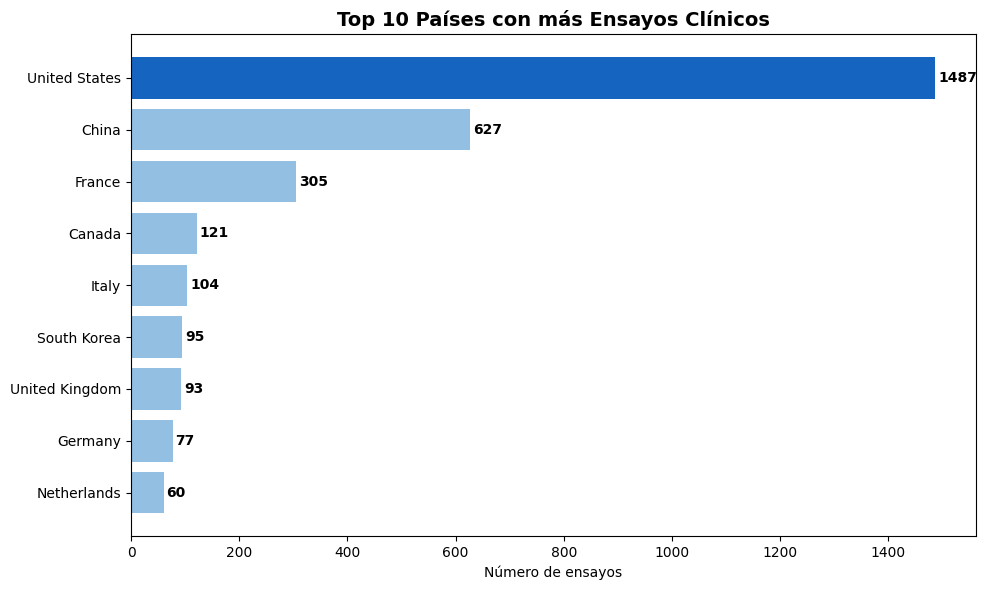

✅ Gráfico guardado


In [4]:
# Hipótesis 2: Países líderes en investigación clínica (paises Top)
fig, ax = plt.subplots(figsize=(10, 6))
top_countries = df["primary_country"].value_counts().head(10)
top_countries = top_countries[top_countries.index != "Unknown"]
colors = ["#1565C0" if c == "United States" else "#93BFE3" for c in top_countries.index]
ax.barh(top_countries.index[::-1], top_countries.values[::-1], color=colors[::-1])
ax.set_title("Top 10 Países con más Ensayos Clínicos", fontsize=14, fontweight="bold")
ax.set_xlabel("Número de ensayos")
for i, v in enumerate(top_countries.values[::-1]):
    ax.text(v + 5, i, str(v), va="center", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}\\data\\clean\\plot_countries.png", dpi=150)
plt.show()
print("✅ Gráfico guardado")

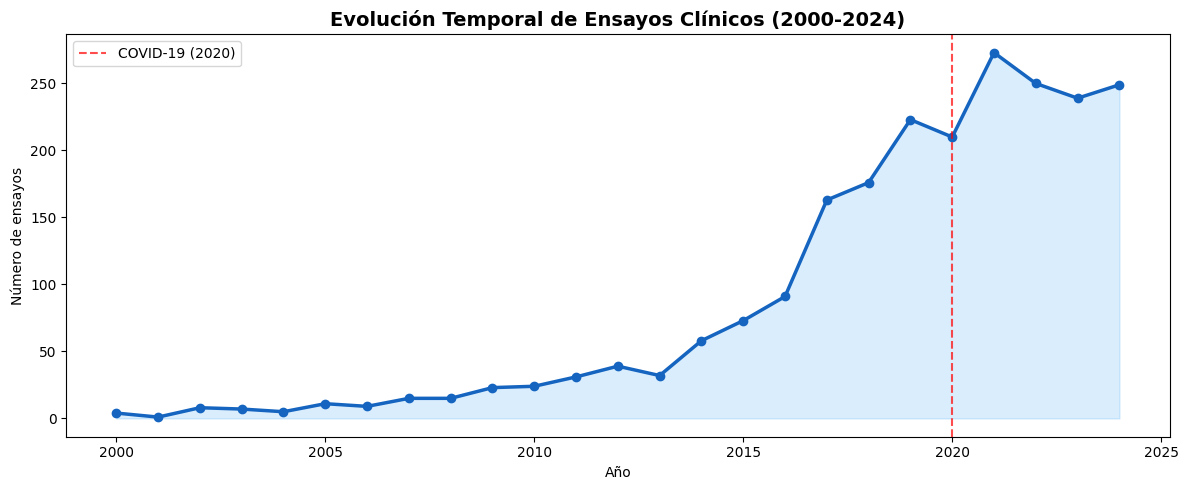

✅ Gráfico guardado


In [6]:
# Hipótesis 3: Evolución temporal de ensayos por año
fig, ax = plt.subplots(figsize=(12, 5))
year_counts = df["start_year"].dropna().value_counts().sort_index()
year_counts = year_counts[(year_counts.index >= 2000) & (year_counts.index <= 2024)]
ax.plot(year_counts.index, year_counts.values, marker="o", color="#1565C0", linewidth=2.5)
ax.fill_between(year_counts.index, year_counts.values, alpha=0.2, color="#42A5F5")
ax.set_title("Evolución Temporal de Ensayos Clínicos (2000-2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Año")
ax.set_ylabel("Número de ensayos")
ax.axvline(x=2020, color="red", linestyle="--", alpha=0.7, label="COVID-19 (2020)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{BASE_PATH}\\data\\clean\\plot_timeline.png", dpi=150)
plt.show()
print("✅ Gráfico guardado")

#Lo que muestra:

2000-2015: crecimiento lento y estable
2015-2019: aceleración notable de la investigación clínica
2020: pequeña caída — COVID-19 interrumpió ensayos en curso
2021: pico máximo — boom post-COVID, muchos ensayos nuevos de vacunas y tratamientos
2022-2024: estabilización en niveles altos

💡 Frase para la presentación: "El COVID-19 no frenó la investigación clínica — la disparó. El pico de 2021 refleja la respuesta global de la ciencia ante la pandemia."

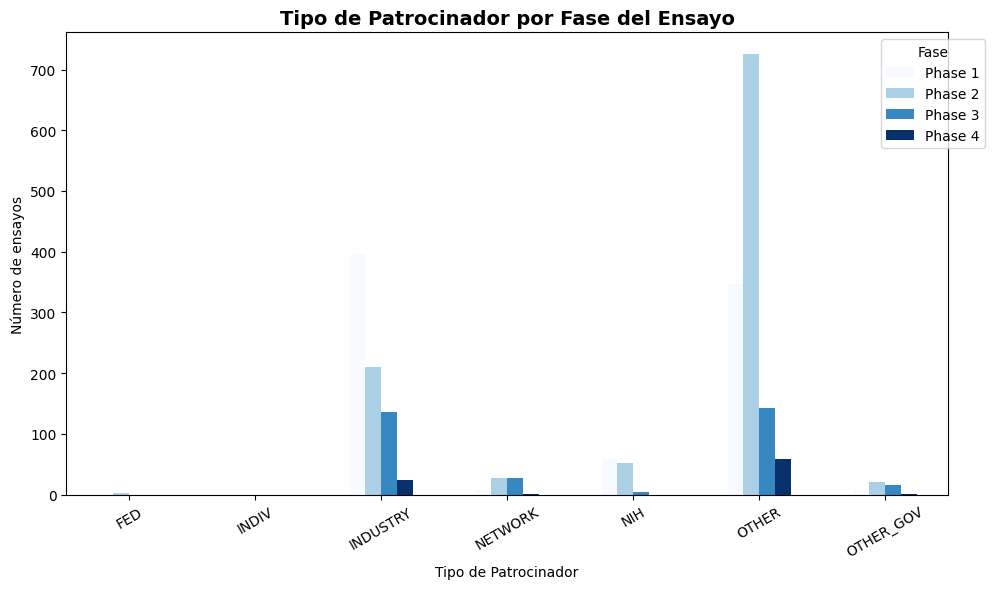

✅ Gráfico guardado


In [7]:
# Hipótesis 4: Relación entre tipo de patrocinador y fase
fig, ax = plt.subplots(figsize=(10, 6))
sponsor_phase = df[df["phase"] != "Unknown"].groupby(["sponsor_class", "phase"]).size().unstack(fill_value=0)
sponsor_phase = sponsor_phase[["Phase 1", "Phase 2", "Phase 3", "Phase 4"]]
sponsor_phase.plot(kind="bar", ax=ax, colormap="Blues")
ax.set_title("Tipo de Patrocinador por Fase del Ensayo", fontsize=14, fontweight="bold")
ax.set_xlabel("Tipo de Patrocinador")
ax.set_ylabel("Número de ensayos")
plt.xticks(rotation=30)
plt.legend(title="Fase", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig(f"{BASE_PATH}\\data\\clean\\plot_sponsor_phase.png", dpi=150)
plt.show()
print("✅ Gráfico guardado")

# Hipótesis 4 confirmada visualmente.Lo que muestra:

INDUSTRY domina en Phase 2 y Phase 3 — la industria farmacéutica invierte en fases avanzadas donde hay retorno comercial
OTHER (universidades, hospitales) lidera en Phase 2 — investigación académica muy activa
NIH presente en fases tempranas — financiación pública en investigación básica
Phase 4 casi inexistente en todos — post-comercialización es rara
💡 Frase para la presentación: "La industria farmacéutica domina las fases avanzadas donde el retorno comercial es mayor, mientras que la investigación académica y pública lidera las fases tempranas de exploración."

In [8]:
# FUNCIONES REUTILIZABLES DEL PROYECTO

def plot_trials_by_phase(df):
    """Genera gráfico de distribución de ensayos por fase."""
    phase_counts = df["phase"].value_counts()
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(phase_counts.index, phase_counts.values, color="#42A5F5")
    ax.set_title("Ensayos por Fase", fontweight="bold")
    ax.set_xlabel("Fase")
    ax.set_ylabel("Número de ensayos")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

def plot_top_countries(df, n=10):
    """Genera gráfico de top N países con más ensayos."""
    top = df["primary_country"].value_counts().head(n)
    top = top[top.index != "Unknown"]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top.index[::-1], top.values[::-1], color="#1565C0")
    ax.set_title(f"Top {n} Países", fontweight="bold")
    ax.set_xlabel("Número de ensayos")
    plt.tight_layout()
    plt.show()

def get_summary(df):
    """Devuelve resumen estadístico del dataset."""
    print(f"Total ensayos: {len(df)}")
    print(f"Paises únicos: {df['primary_country'].nunique()}")
    print(f"Patrocinadores únicos: {df['sponsor'].nunique()}")
    print(f"Rango temporal: {int(df['start_year'].min())} - {int(df['start_year'].max())}")
    print(f"Enrollment medio: {df['enrollment'].mean():.0f} participantes")

print("✅ 3 funciones definidas")

✅ 3 funciones definidas
